<a href="https://colab.research.google.com/github/ayaelsadek/restaurant-cv-demo/blob/main/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Download a public crowd/street video**

In [8]:
import yt_dlp

url = "https://www.youtube.com/watch?v=MNn9qKG2UFI"  # public crowd video

ydl_opts = {
    'format': 'best[ext=mp4][height<=480]',
    'outtmpl': 'test_video.mp4',
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([url])

print("Video downloaded successfully")

[youtube] Extracting URL: https://www.youtube.com/watch?v=MNn9qKG2UFI
[youtube] MNn9qKG2UFI: Downloading webpage


[youtube] MNn9qKG2UFI: Downloading android vr player API JSON
[info] MNn9qKG2UFI: Downloading 1 format(s): 18
[download] test_video.mp4 has already been downloaded
[download] 100% of   20.91MiB
Video downloaded successfully


**Run YOLOv8 people detection**

In [16]:
from re import VERBOSE
from ast import mod
from ultralytics import YOLO
import cv2
from IPython.display import display, Image
import ipywidgets as widgets

# Load the YOLOv8 model
model = YOLO('yolov8n.pt')

#open video
cap=cv2.VideoCapture('test_video.mp4')

width=int(cap.get(3))
height=int(cap.get(4))
fps=int(cap.get(cv2.CAP_PROP_FPS))
print(f"Video : {width}x{height} @ {fps}fps")

#output video writer
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('output_video.avi', fourcc,
                     fps, (width, height))
print("VideoWriter opened:", out.isOpened())

frame_count=0
max=frames=200

while cap.isOpened() and frame_count<max:
    # Read a frame from the video
    ret, frame=cap.read()
    if not ret:
      break

    #Run inference
    results=model(frame, verbose=False, conf=0.5)

    #Count people
    people=[box for box in results[0].boxes if int(box.cls)==0]
    count=len(people)

    #Visualize
    annotated_frame=results[0].plot()
    cv2.putText(annotated_frame, f'people detected: {count}', (20, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

    out.write(annotated_frame)
    frame_count+=1
    if frame_count %50==0:
      print(f"Processed {frame_count} frames")

cap.release()
out.release()
print('Done output saved to output.avi')

Video : 640x360 @ 30fps
VideoWriter opened: True
Processed 50 frames
Processed 100 frames
Processed 150 frames
Processed 200 frames
Done output saved to output.avi


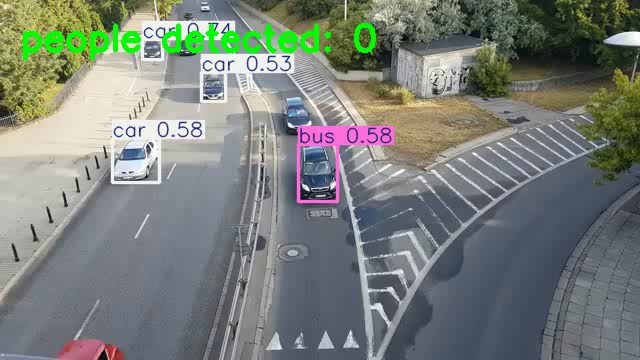

In [17]:
#Extract and display one annotated frame
cap=cv2.VideoCapture('output_video.avi')
ret, frame=cap.read()
cap.release()
_, buffer=cv2.imencode('.jpg', frame)
display(Image(data=buffer.tobytes()))

